## Improve the model by grouping NTAs into PUMAs

Geographic areas are naturally hierarchical—blocks sit inside neighborhoods, and neighborhoods sit inside cities.

In our case, NTAs sit inside broader PUMAs. In this notebook, we group NTAs under their corresponding PUMAs and model them hierarchically. 
This lets the model share information across nearby neighborhoods, so individual NTAs borrow strength from their broader 
PUMA when data is sparse. The result is more stable estimates and more realistic patterns of noise complaints from neighborhood to neighborhood.


This process of making the model Hherarchical models is called partial pooling because they let neighborhoods borrow strength from each other instead of being treated as completely independent.

In [1]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API",
    category=UserWarning,
)

In [2]:
import pymc as pm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
import geopandas as gpd
from keplergl import KeplerGl
from helpers import ( prep_the_data, 
                      export_geo_kepler, 
                      make_daily_table_for_model_with_nta,
                      load_idata,
                      export_idata,
                      compare_models_loo_waic,
                      kepler_typical_week_from_dow_complaint,
                      summarize_lam_posterior
                    )




### Load + prepare data: 2021-2024 

In [3]:
df_puma = pd.read_parquet(
    "../data/processed/features/puma_noise_counts.parquet"
)


In [4]:
df_puma = prep_the_data(df_puma)

In [5]:
df_puma_2021__2024 = df_puma.loc[
    (df_puma["created_bucket"] >= "2021-01-01") &
    (df_puma["created_bucket"] <  "2024-12-31") 
].copy()


In [6]:
df_puma_2021__2024.head()

,puma,complaint_type,descriptor,location_type,created_bucket,time_of_day,complaint_count,nta,area_share_of_puma,nta_name,nta_puma,dow,month,is_weekend,month_year,descriptor_group,dow_complaint
0,4103,Noise,Noise,NR5,2022-06-09,day,1,MN0303,0.403905,East Village,East Village — 4103,Thursday,June,0,June__2022,Other,OTHER__Thursday
1,4103,Noise,"Noise, Barking Dog",NaN,2021-07-10,night,1,MN0303,0.403905,East Village,East Village — 4103,Saturday,July,1,July__2021,Animal,ANIMAL__Saturday
2,4103,Noise,"Noise, Barking Dog",NaN,2021-08-07,day,1,MN0303,0.403905,East Village,East Village — 4103,Saturday,August,1,August__2021,Animal,ANIMAL__Saturday
3,4103,Noise,"Noise, Barking Dog",NaN,2021-08-13,day,1,MN0303,0.403905,East Village,East Village — 4103,Friday,August,0,August__2021,Animal,ANIMAL__Friday
4,4103,Noise,"Noise, Barking Dog",NaN,2021-08-15,night,2,MN0303,0.403905,East Village,East Village — 4103,Sunday,August,1,August__2021,Animal,ANIMAL__Sunday


In [7]:
daily_df, coords = make_daily_table_for_model_with_nta(
    df_puma_2021__2024,
    complaint_col="descriptor_group",
)

This model recognizes that neighborhoods don’t exist in isolation. NTAs are grouped within PUMAs, 
and the model first learns shared weekday patterns at the PUMA level before allowing individual 
NTAs to deviate when the data supports it. 

In [8]:
# daily_df has: puma, nta_name, puma_idx, nta_idx, dow_idx, daily_count

# Build a unique mapping: nta_idx -> puma_idx
nta_puma_map = (
    daily_df[["nta_idx", "puma_idx"]]
    .drop_duplicates()
    .sort_values("nta_idx")
)

# sanity check: each nta maps to exactly 1 puma
assert nta_puma_map["nta_idx"].is_unique, "An NTA maps to multiple PUMAs (check your join)."

nta_to_puma_idx = nta_puma_map["puma_idx"].to_numpy()  # shape (n_nta,)


### Constructing the Group Model 

This is the actual data we observed.

In [9]:
y = daily_df["daily_count"].to_numpy(dtype=int)


This tells the model which NTA each observation belongs to.

In [10]:
nta_idx_obs = daily_df["nta_idx"].to_numpy(dtype=int)

This tells the model what day of the week each observation occurred on.

In [11]:
dow_idx_obs  = daily_df["dow_idx"].to_numpy(dtype=int)

This is the moment where the hierarchy actually happens. Take the PUMA’s weekday pattern, and then add 
this NTA’s adjustment.”

```python
log_lambda = pm.Deterministic(
    "log_lambda",
    mu_puma[nta_to_puma_idx, :] + delta_nta,
)
```

A Deterministic variable is where everything comes together. It isn’t something the model is guessing 
on its own — it’s something the model calculates from what it has already learned.

```python
lam = pm.Deterministic("lam", pm.math.exp(log_lambda), dims=("nta", "dow"))
```

In this case:

    - mu_puma = the PUMA’s weekday baseline

    - delta_nta = the NTA’s adjustment

    - log_lambda = their combined effect
    
    - lam = the final expected number of complaints

So you can think of lam as:

"Given everything the model has learned, this is the expected number of complaints for each NTA on each weekday."

In [12]:
with pm.Model(coords=coords) as m2_puma:

    # PUMA-level weekday baseline on log scale
    mu_puma = pm.Normal("mu_puma", mu=0.0, sigma=1.5, dims=("puma", "dow"))

    # NTA-level deviation around its PUMA baseline
    sigma_nta = pm.Exponential("sigma_nta", 1.0)
    delta_nta = pm.Normal("delta_nta", mu=0.0, sigma=sigma_nta, dims=("nta", "dow"))

    # Build log-rate for every (nta, dow) using NTA->PUMA mapping (NOT per-observation indexing)
    log_lambda = pm.Deterministic(
        "log_lambda",
        mu_puma[nta_to_puma_idx, :] + delta_nta,
        dims=("nta", "dow"),
    )

    lam = pm.Deterministic("lam", pm.math.exp(log_lambda), dims=("nta", "dow"))

    # Likelihood: each observation picks its (nta, dow)
    y_obs = pm.Poisson("y_obs", mu=lam[nta_idx_obs, dow_idx_obs], observed=y)

    idata_nta_puma_pois = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
        idata_kwargs={"log_likelihood": True},
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_puma, sigma_nta, delta_nta]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2666 seconds.
Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 2 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


In [13]:
az.summary(idata_nta_puma_pois)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"mu_puma[4103, Monday]",0.638,1.339,-1.842,3.170,0.031,0.020,1914.0,2547.0,1.00
"mu_puma[4103, Tuesday]",0.648,1.322,-1.823,3.100,0.031,0.020,1815.0,2741.0,1.00
"mu_puma[4103, Wednesday]",0.708,1.321,-1.807,3.138,0.031,0.019,1810.0,2305.0,1.00
"mu_puma[4103, Thursday]",0.775,1.320,-1.586,3.347,0.030,0.021,1960.0,2376.0,1.00
"mu_puma[4103, Friday]",0.745,1.370,-1.823,3.342,0.029,0.020,2177.0,2587.0,1.00
...,...,...,...,...,...,...,...,...,...
"lam[Washington Heights (North), Wednesday]",60.956,1.254,58.501,63.225,0.020,0.025,3837.0,2321.0,1.00
"lam[Washington Heights (North), Thursday]",66.582,1.322,64.283,69.172,0.021,0.025,4035.0,2458.0,1.00
"lam[Washington Heights (North), Friday]",93.353,1.494,90.385,95.985,0.024,0.028,3835.0,2389.0,1.00
"lam[Washington Heights (North), Saturday]",160.775,1.961,157.010,164.334,0.032,0.032,3644.0,2649.0,1.00


###  compare both models
Now that we have both models we want to compare the previous flat model to the current heirarchical model

In [14]:
idata_nta_pois = load_idata("../data/processed/models/model1_nta_pois_idata.nc")

✅ Loaded idata <- ../data/processed/models/model1_nta_pois_idata.nc


#### Build posterior summaries for BOTH models on the same (nta, dow) grid

In [15]:





df_model1 = summarize_lam_posterior(idata_nta_pois, "lam_mean_nonhier")
df_model3 = summarize_lam_posterior(idata_nta_puma_pois, "lam_mean_hier")

df_shrink = df_model1.merge(df_model3, on=["nta", "dow"], how="inner")

nta_lookup = (
    df_puma_2021__2024[["nta_name", "puma"]]
    .drop_duplicates()
    .assign(
        nta=lambda d: d["nta_name"].str.strip(),
        nta_puma=lambda d: d["nta_name"].str.strip() + " — PUMA " + d["puma"].astype("string")
    )
)

weekday_mean = (
    df_puma_2021__2024
    .groupby(["nta_name", "dow", "created_bucket"], as_index=False)
    .agg(daily_complaints=("complaint_count", "sum"))
    .rename(columns={"nta_name": "nta"})
    .groupby(["nta", "dow"], as_index=False)
    .agg(mean_complaint_count=("daily_complaints", "mean"))
)

df_shrink = (
    df_shrink
    .merge(nta_lookup[["nta", "nta_puma"]], on="nta", how="left")
    .merge(weekday_mean, on=["nta", "dow"], how="left")
)

df_shrink["shrinkage"] = df_shrink["lam_mean_hier"] - df_shrink["lam_mean_nonhier"]
df_shrink["abs_shrinkage"] = df_shrink["shrinkage"].abs()
df_shrink["pct_shrinkage"] = np.where(
    df_shrink["lam_mean_nonhier"].abs() > 1e-9,
    df_shrink["shrinkage"] / df_shrink["lam_mean_nonhier"],
    np.nan,
)

df_shrink.head()


,nta,dow,lam_mean_nonhier,lam_mean_nonhier_high_90,lam_mean_nonhier_low_90,lam_mean_nonhier_width_90,lam_mean_hier,lam_mean_hier_high_90,lam_mean_hier_low_90,lam_mean_hier_width_90,nta_puma,mean_complaint_count,shrinkage,abs_shrinkage,pct_shrinkage
0,Annadale-Huguenot-Prince's Bay-Woodrow,Monday,6.630604,7.268630,5.944998,1.323632,6.767475,7.453449,6.029359,1.424091,Annadale-Huguenot-Prince's Bay-Woodrow — PUMA ...,6.769231,0.136871,0.136871,0.020642
1,Annadale-Huguenot-Prince's Bay-Woodrow,Tuesday,8.049389,8.825830,7.340610,1.485220,8.246580,8.995852,7.521392,1.474461,Annadale-Huguenot-Prince's Bay-Woodrow — PUMA ...,8.243243,0.197191,0.197191,0.024498
2,Annadale-Huguenot-Prince's Bay-Woodrow,Wednesday,7.971724,8.652166,7.210386,1.441780,8.136387,8.882789,7.371348,1.511441,Annadale-Huguenot-Prince's Bay-Woodrow — PUMA ...,8.150000,0.164663,0.164663,0.020656
3,Annadale-Huguenot-Prince's Bay-Woodrow,Thursday,8.202429,8.941482,7.468198,1.473285,8.377994,9.063577,7.582603,1.480974,Annadale-Huguenot-Prince's Bay-Woodrow — PUMA ...,8.384615,0.175565,0.175565,0.021404
4,Annadale-Huguenot-Prince's Bay-Woodrow,Friday,9.489920,10.249218,8.759043,1.490175,9.687496,10.448317,8.939294,1.509023,Annadale-Huguenot-Prince's Bay-Woodrow — PUMA ...,9.690476,0.197575,0.197575,0.020820


This chart shows a shrinkage plot comparing the non-hierarchical Model 1 to the hierarchical Model 2.

Each point represents a single (NTA, day-of-week) combination. The x-axis shows the Model 1 posterior mean, and the y-axis shows the Model 2 posterior mean.

Points along the diagonal indicate little to no shrinkage, meaning both models agree. At lower complaint levels, estimates are nearly identical.

At higher complaint levels, some points lie above the diagonal, indicating that the hierarchical model slightly increases those estimates—suggesting 
it is correcting mild underestimation in the non-hierarchical model.

Overall, the effect is modest, showing that the hierarchical model is stabilizing estimates without significantly altering the underlying signal.

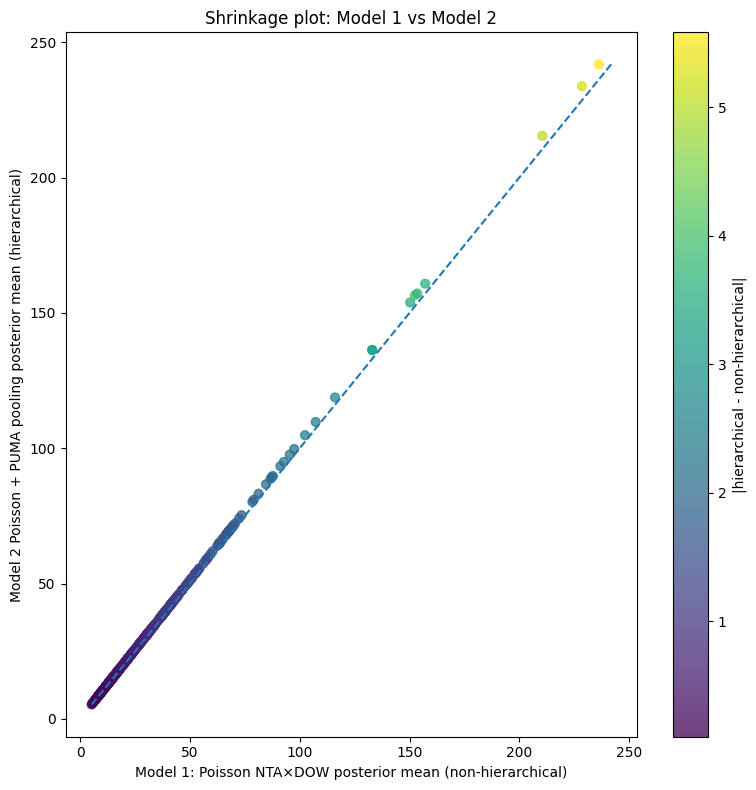

In [16]:

# --- Main shrinkage plot: non-hierarchical posterior mean vs hierarchical posterior mean

plt.figure(figsize=(8, 8))

ax = plt.gca()
scatter = ax.scatter(
    df_shrink["lam_mean_nonhier"],
    df_shrink["lam_mean_hier"],
    c=df_shrink["abs_shrinkage"],
    s=40,
    alpha=0.75,
)

min_val = min(df_shrink["lam_mean_nonhier"].min(), df_shrink["lam_mean_hier"].min())
max_val = max(df_shrink["lam_mean_nonhier"].max(), df_shrink["lam_mean_hier"].max())

ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")
ax.set_xlabel("Model 1: Poisson NTA×DOW posterior mean (non-hierarchical)")
ax.set_ylabel("Model 2 Poisson + PUMA pooling posterior mean (hierarchical)")
ax.set_title("Shrinkage plot: Model 1 vs Model 2")

cbar = plt.colorbar(scatter)
cbar.set_label("|hierarchical - non-hierarchical|")

plt.tight_layout()
plt.show()


In [17]:

# --- Optional: inspect the strongest shrinkage cases

df_shrink.sort_values("abs_shrinkage", ascending=False)[
    [
        "nta_puma",
        "dow",
        "lam_mean_nonhier",
        "lam_mean_hier",
        "mean_complaint_count",
        "shrinkage",
        "pct_shrinkage",
    ]
].head(15)


,nta_puma,dow,lam_mean_nonhier,lam_mean_hier,mean_complaint_count,shrinkage,pct_shrinkage
181,Eastchester-Edenwald-Baychester — PUMA 4212,Sunday,236.231802,241.815638,241.857143,5.583837,0.023637
180,Eastchester-Edenwald-Baychester — PUMA 4212,Saturday,228.500736,233.726140,233.790698,5.225403,0.022868
384,Washington Heights (North) — PUMA 4112,Sunday,210.423913,215.422065,215.428571,4.998152,0.023753
176,Eastchester-Edenwald-Baychester — PUMA 4212,Tuesday,152.379475,156.477086,156.486486,4.097611,0.026891
370,University Heights (South)-Morris Heights — PU...,Sunday,153.451960,157.134972,157.095238,3.683012,0.024001
383,Washington Heights (North) — PUMA 4112,Saturday,157.101526,160.774924,160.767442,3.673398,0.023382
118,Concourse-Concourse Village — PUMA 4204,Sunday,150.293554,153.828619,153.857143,3.535065,0.023521
175,Eastchester-Edenwald-Baychester — PUMA 4212,Monday,132.950689,136.330792,136.307692,3.380103,0.025424
179,Eastchester-Edenwald-Baychester — PUMA 4212,Friday,133.039240,136.217189,136.190476,3.177949,0.023887
55,Bronx Park — PUMA 4263,Sunday,116.056825,118.762851,118.785714,2.706027,0.023316


This forest plot highlights the largest shrinkage cases between Model 1 and Model 2. The hierarchical model consistently shifts 
estimates slightly to the right, indicating modest upward adjustments in high-complaint NTAs.

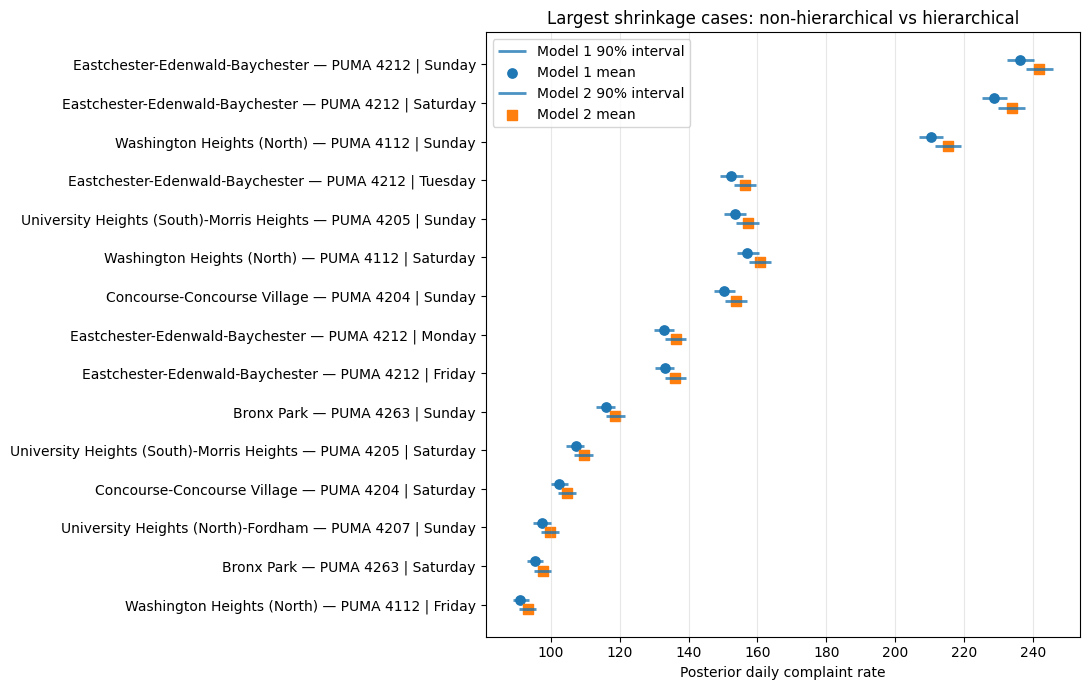

In [18]:

# --- Forest-style comparison for the largest shrinkage cases

top_shrink = (
    df_shrink
    .sort_values("abs_shrinkage", ascending=False)
    .head(15)
    .iloc[::-1]
    .copy()
)

top_shrink["label"] = top_shrink["nta_puma"].astype(str) + " | " + top_shrink["dow"].astype(str)
y = np.arange(len(top_shrink))

plt.figure(figsize=(11, 7))

# Model 1 interval
plt.hlines(
    y=y + 0.12,
    xmin=top_shrink["lam_mean_nonhier_low_90"],
    xmax=top_shrink["lam_mean_nonhier_high_90"],
    linewidth=2,
    alpha=0.8,
    label="Model 1 90% interval",
)
plt.scatter(
    top_shrink["lam_mean_nonhier"],
    y + 0.12,
    marker="o",
    s=45,
    label="Model 1 mean",
)

# Model 2 interval
plt.hlines(
    y=y - 0.12,
    xmin=top_shrink["lam_mean_hier_low_90"],
    xmax=top_shrink["lam_mean_hier_high_90"],
    linewidth=2,
    alpha=0.8,
    label="Model 2 90% interval",
)
plt.scatter(
    top_shrink["lam_mean_hier"],
    y - 0.12,
    marker="s",
    s=45,
    label="Model 2 mean",
)

plt.yticks(y, top_shrink["label"])
plt.xlabel("Posterior daily complaint rate")
plt.title("Largest shrinkage cases: non-hierarchical vs hierarchical")
plt.grid(axis="x", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


### Model Comparison: Predictive Performance

This table is comparing two different models and asking a simple question:

Which model does a better job predicting new, unseen noise complaint data?

To answer that, we use two standard scoring methods (LOO and WAIC). You don’t need to understand the math 
behind them—just how to interpret the results.

The ELPD is the most important value in the table. Think of this as a prediction score.
    -  Higher (or less negative) = better predictions

In this cas, the Poisson + PUMA pooling model performs better than the flat NTA×weekday model.

In [19]:
loo_table, waic_table = compare_models_loo_waic(idata_nta_pois, idata_nta_puma_pois, m2_name="Poisson NTA×DOW", m3_name="Poisson + PUMA pooling")


/Users/mozilla/Library/Caches/pypoetry/virtualenvs/nyc-311-bayesian-noise-models-pweGKFeb-py3.12/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/mozilla/Library/Caches/pypoetry/virtualenvs/nyc-311-bayesian-noise-models-pweGKFeb-py3.12/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Poisson + PUMA pooling,0,-163746.014699,5719.328467,0.000000,0.5,10503.281191,0.000000,True,log
Poisson NTA×DOW,1,-163838.500301,5755.054727,92.485603,0.5,10630.828058,158.240794,True,log


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Poisson + PUMA pooling,0,-167848.614714,9821.928482,0.000000,0.5,11712.784314,0.000000,True,log
Poisson NTA×DOW,1,-168209.883733,10126.438158,361.269019,0.5,11934.808954,262.674224,True,log


This chart compares the predictive performance of Model 1 (Poisson NTA×DOW) and Model 2 (Poisson + PUMA pooling). 
The hierarchical model (Model 2) performs slightly better, though the improvement is modest.

In [20]:
# Convert to DataFrame (if not already)
df_loo = loo_table.copy()

# Reset index to get model names as a column
df_loo = df_loo.reset_index().rename(columns={"index": "model"})

# Keep only what we need
df_loo_plot = df_loo[["model", "elpd_loo", "se"]]

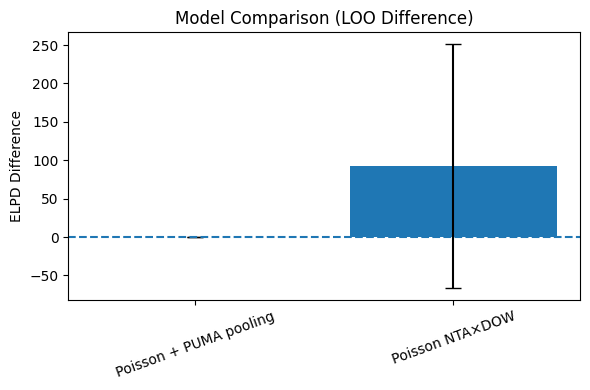

In [21]:
plt.figure(figsize=(6, 4))

plt.bar(
    df_loo["model"],
    df_loo["elpd_diff"],
    yerr=df_loo["dse"],
    capsize=6
)

plt.axhline(0, linestyle="--")

plt.ylabel("ELPD Difference")
plt.title("Model Comparison (LOO Difference)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Export for visualization

Finally we follow similar steps as in section 2 for preparring to export and visualize in Kepler

In [22]:
# --- Posterior draws of lambda[nta, dow]
lam_post = idata_nta_puma_pois.posterior["lam"]  # dims: chain, draw, nta, dow

# Posterior mean
lam_mean = (
    lam_post
    .mean(dim=("chain", "draw"))
    .to_dataframe(name="lam_mean")
    .reset_index()
)

# 90% HDI
hdi_ds = az.hdi(lam_post, hdi_prob=0.9)
hdi_df = (
    hdi_ds["lam"]
    .to_dataframe(name="lam_hdi")
    .reset_index()
    .pivot_table(
        index=["nta", "dow"],
        columns="hdi",
        values="lam_hdi"
    )
    .reset_index()
    .rename(columns={"lower": "lam_low_90", "higher": "lam_high_90"})
)

# Combine
df_post = lam_mean.merge(hdi_df, on=["nta", "dow"], how="left")
df_post["lam_width_90"] = df_post["lam_high_90"] - df_post["lam_low_90"]

df_post.head()


,nta,dow,lam_mean,lam_high_90,lam_low_90,lam_width_90
0,Annadale-Huguenot-Prince's Bay-Woodrow,Monday,6.767475,7.453449,6.029359,1.424091
1,Annadale-Huguenot-Prince's Bay-Woodrow,Tuesday,8.246580,8.995852,7.521392,1.474461
2,Annadale-Huguenot-Prince's Bay-Woodrow,Wednesday,8.136387,8.882789,7.371348,1.511441
3,Annadale-Huguenot-Prince's Bay-Woodrow,Thursday,8.377994,9.063577,7.582603,1.480974
4,Annadale-Huguenot-Prince's Bay-Woodrow,Friday,9.687496,10.448317,8.939294,1.509023


In [23]:
# --- Map weekday → synthetic date
dow_to_date = {
    "Monday":    "2000-01-03",
    "Tuesday":   "2000-01-04",
    "Wednesday": "2000-01-05",
    "Thursday":  "2000-01-06",
    "Friday":    "2000-01-07",
    "Saturday":  "2000-01-08",
    "Sunday":    "2000-01-09",
}

df_post["date"] = pd.to_datetime(df_post["dow"].map(dow_to_date), errors="coerce").astype("datetime64[ns]")


nta_lookup = (
    df_puma_2021__2024[["nta_name", "puma"]]
        .drop_duplicates()
        .assign(
            nta=lambda d: d["nta_name"].str.strip(),
            nta_puma=lambda d: d["nta_name"].str.strip()
                              + " — PUMA "
                              + d["puma"].astype("string")
        )
)

df_post = df_post.merge(
    nta_lookup[["nta", "nta_puma"]],
    on="nta",
    how="left"
)

daily_counts = (
    df_puma_2021__2024
    .groupby(["nta_name", "dow", "created_bucket"])
    .agg(daily_complaints=("complaint_count", "sum"))
    .reset_index()
    .rename(columns={"nta_name": "nta"})
)

weekday_mean = (
    daily_counts
    .groupby(["nta", "dow"], as_index=False)
    .agg(mean_complaint_count=("daily_complaints", "mean"))
)

df_post = df_post.merge(
    weekday_mean,
    on=["nta", "dow"],
    how="left"
)

In [24]:
gdf_kepler = kepler_typical_week_from_dow_complaint(
    df_post,
    geojson_path="../data/raw/nyc/geographies/nyc_ntas_2020.geojson",
    df_key="nta",
    geo_key="NTAName",
    out_path="../data/processed/kepler/03_01_nyc_nta_typical_week_model2_posterior_2021__2024.geojson",
)


✅ Kepler GeoJSON written to: ../data/processed/kepler/03_01_nyc_nta_typical_week_model2_posterior_2021__2024.geojson


In [25]:
df_post

,nta,dow,lam_mean,lam_high_90,lam_low_90,lam_width_90,date,nta_puma,mean_complaint_count
0,Annadale-Huguenot-Prince's Bay-Woodrow,Monday,6.767475,7.453449,6.029359,1.424091,2000-01-03,Annadale-Huguenot-Prince's Bay-Woodrow — PUMA ...,6.769231
1,Annadale-Huguenot-Prince's Bay-Woodrow,Tuesday,8.246580,8.995852,7.521392,1.474461,2000-01-04,Annadale-Huguenot-Prince's Bay-Woodrow — PUMA ...,8.243243
2,Annadale-Huguenot-Prince's Bay-Woodrow,Wednesday,8.136387,8.882789,7.371348,1.511441,2000-01-05,Annadale-Huguenot-Prince's Bay-Woodrow — PUMA ...,8.150000
3,Annadale-Huguenot-Prince's Bay-Woodrow,Thursday,8.377994,9.063577,7.582603,1.480974,2000-01-06,Annadale-Huguenot-Prince's Bay-Woodrow — PUMA ...,8.384615
4,Annadale-Huguenot-Prince's Bay-Woodrow,Friday,9.687496,10.448317,8.939294,1.509023,2000-01-07,Annadale-Huguenot-Prince's Bay-Woodrow — PUMA ...,9.690476
...,...,...,...,...,...,...,...,...,...
380,Washington Heights (North),Wednesday,60.956410,63.195386,59.007788,4.187598,2000-01-05,Washington Heights (North) — PUMA 4112,60.925000
381,Washington Heights (North),Thursday,66.582265,68.689701,64.360458,4.329243,2000-01-06,Washington Heights (North) — PUMA 4112,66.564103
382,Washington Heights (North),Friday,93.352659,95.745889,90.843092,4.902798,2000-01-07,Washington Heights (North) — PUMA 4112,93.333333
383,Washington Heights (North),Saturday,160.774924,163.983161,157.634885,6.348276,2000-01-08,Washington Heights (North) — PUMA 4112,160.767442


### export for prediction

In [26]:

export_idata(idata_nta_puma_pois, "../data/processed/models/model2_nta_puma_idata.nc")

✅ Saved idata -> ../data/processed/models/model2_nta_puma_idata.nc


'../data/processed/models/model2_nta_puma_idata.nc'